# Presentación grabada
En esta clase de aprendizaje supervisado abordamos el tema de Support Vector Machine (SVM), junto con la función del Gradiente Estocástico Descendiente (SGD) utilizando la librería scikit-learn, la cual nos permite probar el resultado de diferentes clasificadores lineales fácilmente. Junto con los modelos que vimos las semanas anteriores tenemos un panorama de varios modelos de clasificación que podemos utilizar.
Consigna: deberás elegir 2 modelos de clasificación de los vistos en el bloque y utilizando un dataset de tu interés aplicar ambos modelos para resolver un problema de aprendizaje automático. Deberás entregar la notebook en tu repositorio y además un video de no más de 10 minutos donde expliques cómo cada modelo elegido resuelve el problema, qué evaluación podemos hacer de cada modelo y en conclusión cuál modelo considerás que aborda mejor el problema.


## Acerca del dataset


*  Información de atributos: (clases: comestible=e, venenoso=p)

* Forma de tapa: campana=B,cónica=C,convexa=X,Flat=F, Nudosa=K,Hundida=S

* Superficie de la tapa: fibrosa=F,surcos=G,escamos=Y,lisa=S

* Color de la gorra: marrón=n,buff=b,canela=c,gris=g,verde=r,rosa=p,púrpura=u,rojo=e,blanco=w,amarillo=y

* Moretones: moretones=T,no=F

* olor: almendra=a,anís=l,creosoto=c,fishy=y,foul=f,musty=m,none=n,pungent=p,picante=s

* Apegamiento branquial: adjunto=a,descendente=d,libre=f,notched=n

* Espaciado branquial: cerca=c,aglomerado=w,distante=d

* Tamaño branquial: ancho=b, estrecho=n

* Color branquial: negro=k,marrón=n,buff=b,chocolate=h,gris=g, verde=r,naranja=o,rosa=p,púrpura=u,rojo=e,blanco=w,amarillo=y

* forma de tallo: agrandando=e, afilando=t

* raíz-tallo: bulbosa=b,club=c,cup=u,igual=e,rizomorfos=z,enraizados=r,faltante=?

* Superficie-del tallo-sobre el anillo: fibroso=F,escamoso=Y,sedoso=K,liso=S

* superficie-tallo-debajo del anillo: fibroso=f,escamos=y,sedoso=k,liso=s

* color-tallo-arriba-de-anillo: marrón=n,buff=b,canela=c,gray=g,naranja=o,rosa=p,rojo=e,blanco=w,amarillo=y

* color-tallo-debajo del anillo: marrón=n,buff=b,canela=c,gray=g,naranja=o,rosa=p,rojo=e,blanco=w,amarillo=y

* tipo velo: parcial=p,universal=u

* Color del velo: marrón=naranja=o,blanco=w, amarillo=y

* número de anillo: ninguno=n,uno=o,dos=t

* ring-type: cobwebby=c,evanescent=e,flaring=f,large=l,none=n,pendant=p,sheathing=s,zone=z

* spore-print-color: black=k,brown=n,buff=b,chocolate=h,green=r,orange=o,purple=u,white=w,yellow=y

* population: abundant=a,clustered=c,numerous=n,scattered=s,several=v,solitary=y

* habitat: grasses=g,leaves=l,meadows=m,paths=p,urban=u,waste=w,woods=d




### Importacion de librerias

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt


### Carga de datos

In [ ]:
setas = pd.read_csv('mushrooms.csv')
setas.head()


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### Exploracion de datos


Shape del dataset: (8124, 23)

Tipos de datos:
class                       object
cap-shape                   object
cap-surface                 object
cap-color                   object
bruises                     object
odor                        object
gill-attachment             object
gill-spacing                object
gill-size                   object
gill-color                  object
stalk-shape                 object
stalk-root                  object
stalk-surface-above-ring    object
stalk-surface-below-ring    object
stalk-color-above-ring      object
stalk-color-below-ring      object
veil-type                   object
veil-color                  object
ring-number                 object
ring-type                   object
spore-print-color           object
population                  object
habitat                     object
dtype: object

Distribución de clases:
class
e    4208
p    3916
Name: count, dtype: int64


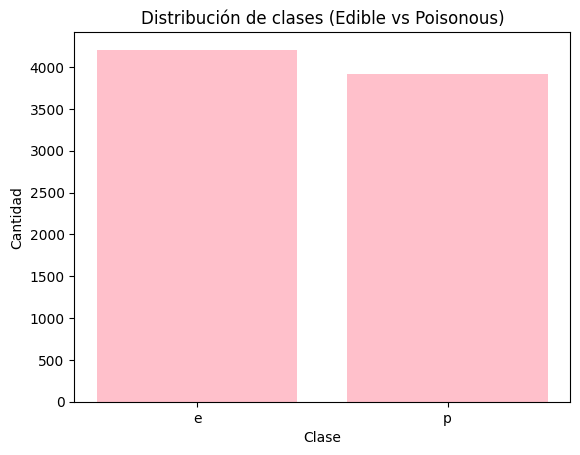


Distribución de la variable 'odor':
odor
n    3528
f    2160
s     576
y     576
a     400
l     400
p     256
c     192
m      36
Name: count, dtype: int64


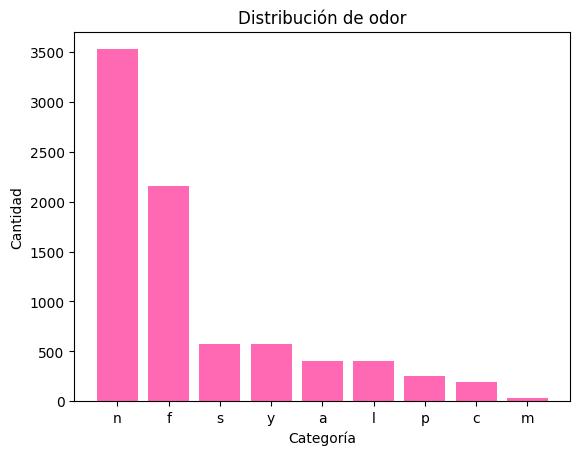

In [ ]:
# Dimensiones
print("\nShape del dataset:", setas.shape)

# Tipos de datos
print("\nTipos de datos:")
print(setas.dtypes)

# Distribución de la variable objetivo
print("\nDistribución de clases:")
print(setas['class'].value_counts())

# Gráfico de distribución de clases
class_counts = setas['class'].value_counts()
plt.figure()
plt.bar(class_counts.index, class_counts.values, color='pink')
plt.title("Distribución de clases (Edible vs Poisonous)")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

# Análisis de una variable (ej: odor)
print("\nDistribución de la variable 'odor':")
print(setas['odor'].value_counts())

odor_counts = setas['odor'].value_counts()
plt.figure()
plt.bar(odor_counts.index, odor_counts.values, color='hotpink')
plt.title("Distribución de odor")
plt.xlabel("Categoría")
plt.ylabel("Cantidad")
plt.show()

### Limpieza de datos

In [ ]:
# Nulos
print(setas.isnull().sum())

# Duplicados
print("Duplicados:", setas.duplicated().sum())

# Encoding
le = LabelEncoder()
for col in setas.columns:
    setas[col] = le.fit_transform(setas[col])

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64
Duplicados: 0


### Definicion de variables


In [ ]:
X = setas.drop("class", axis=1)
y = setas["class"]

### Division de datos de entrenamiento  y prueba

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# MODELOS

### SCM

In [ ]:
model_svm = SVC()
model_svm.fit(X_train, y_train)
pred_svm = model_svm.predict(X_test)

### Metricas


In [ ]:
svm_acc = accuracy_score(y_test, pred_svm)
print("\nSVM Accuracy:", svm_acc)
print(classification_report(y_test, pred_svm))


SVM Accuracy: 0.9926153846153846
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       843
           1       1.00      0.99      0.99       782

    accuracy                           0.99      1625
   macro avg       0.99      0.99      0.99      1625
weighted avg       0.99      0.99      0.99      1625



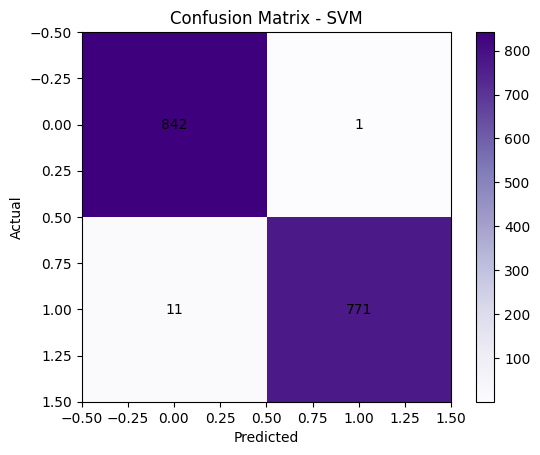

In [ ]:
cm_svm = confusion_matrix(y_test, pred_svm)
plt.figure()
plt.imshow(cm_svm, cmap='Purples')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm_svm.shape[0]):
    for j in range(cm_svm.shape[1]):
        plt.text(j, i, cm_svm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

### Regresion Logistica

In [ ]:
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)
pred_lr = model_lr.predict(X_test)

### Metricas

In [ ]:
lr_acc = accuracy_score(y_test, pred_lr)
print("Logistic Accuracy:", lr_acc)
print(classification_report(y_test, pred_lr))

Logistic Accuracy: 0.9476923076923077
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       843
           1       0.94      0.95      0.95       782

    accuracy                           0.95      1625
   macro avg       0.95      0.95      0.95      1625
weighted avg       0.95      0.95      0.95      1625



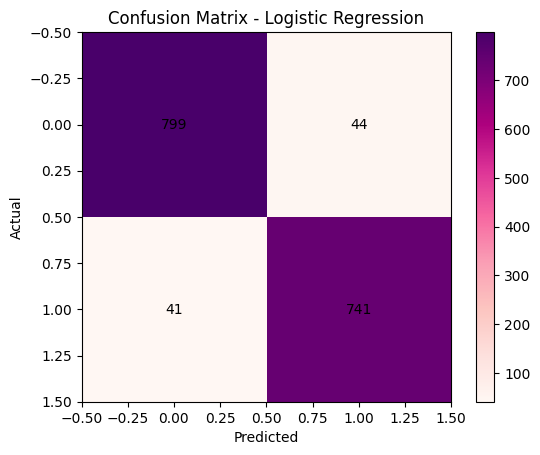

In [ ]:
cm_lr = confusion_matrix(y_test, pred_lr)
plt.figure()
plt.imshow(cm_lr, cmap='RdPu')  # escala magenta
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm_lr.shape[0]):
    for j in range(cm_lr.shape[1]):
        plt.text(j, i, cm_lr[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

### Comparacion


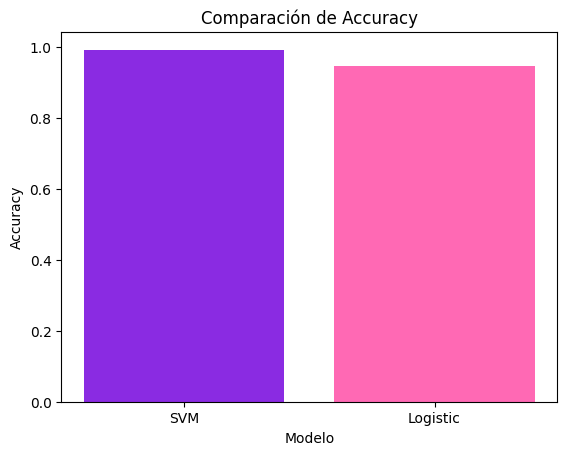

In [ ]:
plt.figure()
plt.bar(["SVM", "Logistic"], [svm_acc, lr_acc],
        color=["#8a2be2", "#ff69b4"])  # violeta (SVM), rosa (Logistic)
plt.title("Comparación de Accuracy")
plt.xlabel("Modelo")
plt.ylabel("Accuracy")
plt.show()

#Conclusion

En este trabajo se abordó un problema de clasificación supervisada utilizando el dataset de *Mushroom*, cuyo objetivo fue predecir si un hongo es comestible o venenoso a partir de sus características físicas. Para ello, se realizó un proceso completo que incluyó la exploración de datos (EDA), el preprocesamiento mediante técnicas de ETL y la aplicación de dos modelos de clasificación: Support Vector Machine (SVM) y Regresión Logística. Durante la etapa de exploración se pudo observar que el dataset está bien estructurado, sin valores nulos y con una distribución de clases relativamente equilibrada, lo cual favorece el desempeño de los modelos.

En cuanto a los resultados obtenidos, el modelo SVM mostró un rendimiento sobresaliente. Su matriz de confusión indica 842 verdaderos negativos, 1 falso positivo, 11 falsos negativos y 771 verdaderos positivos, lo que implica que solo cometió 12 errores en total. Esto se traduce en un accuracy cercano al 99%, evidenciando una excelente capacidad para separar correctamente las clases y minimizar tanto los falsos positivos como los falsos negativos. Por otro lado, la Regresión Logística también presentó un buen desempeño, aunque inferior al de SVM. En este caso, la matriz de confusión arrojó 799 verdaderos negativos, 44 falsos positivos, 41 falsos negativos y 715 verdaderos positivos, acumulando un total de 85 errores y un accuracy aproximado del 97%. Si bien estos resultados siguen siendo altos, se observa una mayor cantidad de errores, especialmente en la clasificación de ambas clases.

Al comparar ambos modelos, se evidencia que SVM logra una mejor separación de los datos, lo que le permite reducir significativamente los errores en comparación con la Regresión Logística. Esta diferencia puede explicarse por la capacidad de SVM para encontrar hiperplanos óptimos incluso en espacios de alta dimensionalidad, mientras que la Regresión Logística, al ser un modelo lineal más simple, puede tener limitaciones cuando la separación entre clases no es completamente lineal. Sin embargo, es importante destacar que la Regresión Logística presenta ventajas en términos de simplicidad, velocidad de entrenamiento e interpretabilidad, lo que la convierte en una opción válida en contextos donde estos aspectos son prioritarios.

En conclusión, ambos modelos resultaron adecuados para resolver el problema planteado, obteniendo métricas de rendimiento muy elevadas debido a la naturaleza del dataset, que presenta patrones claros y fácilmente separables. No obstante, el modelo SVM se posiciona como la mejor opción en este caso, ya que logra una mayor precisión y una menor cantidad de errores. Este análisis pone en evidencia la importancia de comparar distintos modelos y no quedarse únicamente con uno, ya que la elección final dependerá tanto del rendimiento como de las características y necesidades específicas del problema a resolver.
